# SaaS Customer 360 Analysis

**Objective:** Clean, validate, combine, and analyze the SaaS customer data to build a Customer 360 analytical dataset.

This notebook follows the required pipeline:

1. Load and inspect all CSV files.
2. Clean each dataset independently.
3. Validate duplicates, missing values, dates and suspicious values.
4. Concat the four quarterly transaction tables.
5. merge relevant datasets into a customer-level analytical dataset.
6. Create business KPIs and answer business questions.
7. Build visualizations.
8. Summary and recommendations.



In [1100]:
#import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



<a id="Load and inspect all CSV files."></a>
## Load and inspect all CSV files.

In [1101]:
# Load the CSV files

customers = pd.read_csv(r'D:\\Data Analysis\\Python\\Datasets\\Customer 360\\customers.csv')
subscriptions = pd.read_csv(r'D:\\Data Analysis\\Python\\Datasets\\Customer 360\\subscriptions.csv')
campaign_interactions = pd.read_csv(r'D:\\Data Analysis\\Python\\Datasets\\Customer 360\\campaign_interactions.csv')
marketing_campaigns = pd.read_csv(r'D:\\Data Analysis\\Python\\Datasets\\Customer 360\\marketing_campaigns.csv')
support_tickets = pd.read_csv(r'D:\\Data Analysis\\Python\\Datasets\\Customer 360\\support_tickets.csv')
transactions_q1 = pd.read_csv(r'D:\\Data Analysis\\Python\\Datasets\\Customer 360\\transactions_q1.csv')
transactions_q2 = pd.read_csv(r'D:\\Data Analysis\\Python\\Datasets\\Customer 360\\transactions_q2.csv')
transactions_q3 = pd.read_csv(r'D:\\Data Analysis\\Python\\Datasets\\Customer 360\\transactions_q3.csv')    
transactions_q4 = pd.read_csv(r'D:\\Data Analysis\\Python\\Datasets\\Customer 360\\transactions_q4.csv')
print ("Data loaded successfully!")

Data loaded successfully!


## 1. Understand the mess before touching it

In [1102]:
customers.info()
campaign_interactions.info()
marketing_campaigns.info()
subscriptions.info()
support_tickets.info()

<class 'pandas.DataFrame'>
RangeIndex: 1575 entries, 0 to 1574
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   user_id            1575 non-null   int64
 1   full_name          1575 non-null   str  
 2   job_title          1575 non-null   str  
 3   company_name       1507 non-null   str  
 4   email_address      1548 non-null   str  
 5   phone_number       1535 non-null   str  
 6   address            1575 non-null   str  
 7   city               1575 non-null   str  
 8   country            1575 non-null   str  
 9   birth_date         1575 non-null   str  
 10  registration_date  1575 non-null   str  
 11  last_login_date    1499 non-null   str  
 12  account_status     1575 non-null   str  
 13  annual_revenue     1535 non-null   str  
dtypes: int64(1), str(13)
memory usage: 172.4 KB
<class 'pandas.DataFrame'>
RangeIndex: 15100 entries, 0 to 15099
Data columns (total 6 columns):
 #   Column           

In [1103]:
#Needed Functions 

def money_to_numeric(s):
    return pd.to_numeric(
        s.astype("string").str.replace(r"[^0-9.\-]", "", regex=True),
        errors="coerce"
    )

def pct_to_decimal(s):
    return (
        pd.to_numeric(
            s.astype("string").str.replace("%", "", regex=False).str.strip(),
            errors="coerce"
        ) / 100
    )

def parse_mixed_date(x, preferred="dayfirst"):
    if pd.isna(x):
        return pd.NaT
    s = str(x).strip()
    try:
        # ISO dates are unambiguous.
        if re.match(r"^\d{4}[-/]", s):
            return pd.to_datetime(s, errors="coerce")
        # Dates containing month names are also unambiguous.
        if re.search(r"[A-Za-z]", s):
            return pd.to_datetime(s, errors="coerce")
        parts = re.split(r"[/\-]", s)
        if len(parts) == 3:
            a, b, c = map(int, parts)
            if a > 12:
                day, month, year = a, b, c
            elif b > 12:
                month, day, year = a, b, c
            elif preferred == "monthfirst":
                month, day, year = a, b, c
            else:
                day, month, year = a, b, c
            if year < 100:
                year += 2000
            return pd.Timestamp(year, month, day)
    except Exception:
        return pd.NaT
    return pd.to_datetime(s, errors="coerce")

def parse_quarter_date(x, quarter):
    if pd.isna(x):
        return pd.NaT
    s = str(x).strip()
    # First try unambiguous parsing.
    if re.match(r"^\d{4}[-/]", s) or re.search(r"[A-Za-z]", s):
        return parse_mixed_date(s)
    parts = re.split(r"[/\-]", s)
    if len(parts) != 3:
        return parse_mixed_date(s)
    try:
        a, b, c = map(int, parts)
        candidates = []
        if a <= 12 and b <= 12:
            for day, month in [(a, b), (b, a)]:
                try:
                    candidates.append(pd.Timestamp(c, month, day))
                except Exception:
                    pass
        else:
            candidates.append(parse_mixed_date(s))
        q_start = pd.Timestamp(2025, 1 + 3*(quarter-1), 1)
        q_end = q_start + pd.offsets.QuarterEnd(0)
        in_q = [d for d in candidates if q_start <= d <= q_end]
        if in_q:
            return in_q[0]
        return parse_mixed_date(s)
    except Exception:
        return pd.NaT


### Cleaning strategy

- **Text:** strip whitespace and standardize case/categories.
- **Dates:** use a controlled parser for mixed formats. For quarterly transactions, ambiguous dates are resolved using the quarter they belong to.
- **Money:** remove currency symbols/text and convert to numeric USD.
- **Percentages:** convert discount strings to numeric proportions.
- **Duplicates:** remove exact duplicates and resolve duplicated business keys where the duplicate records are the same logical entity.
- **Missing values:** retain legitimate missingness where it has business meaning.
- **Validation:** check uniqueness, referential integrity, date ranges, and post-merge row counts.


## 2. Clean "customers" -- Done

In [1104]:
customers.head()

,user_id,full_name,job_title,company_name,email_address,phone_number,address,city,country,birth_date,registration_date,last_login_date,account_status,annual_revenue
0,1,Sarah Riggs,Financial Analyst,Garcia Inc.,amy50@example.com,531-371-3900x532,"335 Kristina Ranch\nWest Micheleberg, DC 71308",Paris,germany,1967-11-28,2024-07-17,03/25/2025,inactive,464027.88
1,2,Katie Wilson,Data Scientist,Thompson LLC,andersonmichael@example.org,001-350-324-0268,"917 Sonia Cape Suite 700\nBoonechester, TX 14651",Toronto,NETHERLANDS,1979-08-25,2025-05-14,2025-05-23,Active,297513.53
2,3,Laura Gray,COO,Browning Systems,lammarc@example.org,624-999-8569,"18367 Robert Views Suite 661\nRonaldview, MN 2...",Singapore,Spain,1989-04-12,2024-02-12,"Dec 09, 2025",active,515752.34
3,4,Joseph Lawson,IT Specialist,Wells Inc.,deckerchristopher@example.org,001-252-680-9885x1656,"98327 Melanie Keys Suite 149\nPort Roy, OH 81991",Oslo,Italy,1985-09-09,2023-11-23,"Nov 07, 2025",Active,951810.18
4,5,Jeffrey Fowler,Research Scientist,Day Holdings,lynchdiane@example.net,302-444-5502x296,"83667 Moore Inlet\nKimberlyshire, PA 11636",Berlin,DENMARK,1998-11-29,29-07-2023,2023-11-01,Inactive,278199.19


In [1105]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 1575 entries, 0 to 1574
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   user_id            1575 non-null   int64
 1   full_name          1575 non-null   str  
 2   job_title          1575 non-null   str  
 3   company_name       1507 non-null   str  
 4   email_address      1548 non-null   str  
 5   phone_number       1535 non-null   str  
 6   address            1575 non-null   str  
 7   city               1575 non-null   str  
 8   country            1575 non-null   str  
 9   birth_date         1575 non-null   str  
 10  registration_date  1575 non-null   str  
 11  last_login_date    1499 non-null   str  
 12  account_status     1575 non-null   str  
 13  annual_revenue     1535 non-null   str  
dtypes: int64(1), str(13)
memory usage: 172.4 KB


In [1106]:
customers.isna().sum()

user_id               0
full_name             0
job_title             0
company_name         68
email_address        27
phone_number         40
address               0
city                  0
country               0
birth_date            0
registration_date     0
last_login_date      76
account_status        0
annual_revenue       40
dtype: int64

In [1107]:
customers['full_name'] = customers['full_name'].str.strip().str.lower().str.title()
customers['job_title'] = customers['job_title'].str.strip().str.lower().str.title()
customers['company_name'] = customers['company_name'].str.strip().str.lower().str.title()
customers['email_address'] = customers['email_address'].str.strip().str.lower()
customers['address'] = customers['address'].str.strip().str.lower().str.title()
customers['city'] = customers['city'].str.strip().str.lower().str.title()
customers['country'] = customers['country'].str.strip().str.lower().str.title()
customers['account_status'] = customers['account_status'].str.strip().str.lower().str.title()



In [1108]:
customers["birth_date"] = customers["birth_date"].map(parse_mixed_date)
customers["registration_date"] = customers["registration_date"].map(parse_mixed_date)
customers["last_login_date"] = customers["last_login_date"].map(parse_mixed_date)

In [1109]:
customers["annual_revenue"] = money_to_numeric(customers["annual_revenue"])

In [1110]:
customers.nunique()

user_id              1500
full_name            1449
job_title              20
company_name         1220
email_address        1469
phone_number         1463
address              1500
city                   20
country                20
birth_date           1446
registration_date     804
last_login_date       619
account_status          3
annual_revenue       1464
dtype: int64

In [1111]:
customers['user_id'].duplicated().sum()

np.int64(75)

In [1112]:
customers["complete_data"] = customers.notna().sum(axis=1)
customers = (customers.sort_values(["user_id", "complete_data"], ascending=[True, False]).drop_duplicates("user_id", keep="first").drop(columns="complete_data").reset_index(drop=True))


In [1113]:
customers['user_id'].duplicated().sum()

np.int64(0)

In [1114]:
customers.isna().sum()

user_id               0
full_name             0
job_title             0
company_name         61
email_address        26
phone_number         37
address               0
city                  0
country               0
birth_date            0
registration_date     0
last_login_date      72
account_status        0
annual_revenue       42
dtype: int64

In [1115]:
customers['user_id'] = customers['user_id'].astype(str)

## 3. Clean "marketing_campaigns" -- Done

In [1116]:
marketing_campaigns.head(50)


,campaign_id,campaign_name,channel,campaign_type,start_date,budget
0,CMP-0001,Synergistic logistical structure,Facebook,Acquisition,16-12-2025,"25,610.55"
1,CMP-0002,Cross-platform zero administration policy,Referral,Acquisition,26/04/2025,"$24,239.16"
2,CMP-0003,Organic clear-thinking product,linkedin,Upsell,2025-09-05,"$8,895.16"
3,CMP-0004,Advanced encompassing application,email,Acquisition,2025-09-10,$9115
4,CMP-0005,Re-contextualized systematic data-warehouse,LinkedIn,Brand Awareness,29-05-2025,"15,765.50 USD"
5,CMP-0006,Enterprise-wide explicit circuit,Webinar,upsell,13-01-2025,33603.21
6,CMP-0007,Grass-roots zero-defect customer loyalty,Facebook,Brand Awareness,"Jun 15, 2025",22747.53
7,CMP-0008,Self-enabling zero administration alliance,Webinar,RETENTION,"Jun 29, 2025",$38082
8,CMP-0009,Assimilated reciprocal project,Webinar,Brand Awareness,2025-03-28,"47,519.67 USD"
9,CMP-0010,Configurable systemic support,Webinar,RETENTION,"Jul 07, 2025","32,244.60"


In [1117]:
marketing_campaigns.isna().sum()

campaign_id      0
campaign_name    0
channel          0
campaign_type    0
start_date       0
budget           0
dtype: int64

In [1118]:
marketing_campaigns['campaign_id'] = marketing_campaigns['campaign_id'].str.strip().str.lower()
marketing_campaigns['campaign_name'] = marketing_campaigns['campaign_name'].str.strip().str.lower().str.title()
marketing_campaigns['channel'] = marketing_campaigns['channel'].str.strip().str.lower().str.title()
marketing_campaigns['campaign_type'] = marketing_campaigns['campaign_type'].str.strip().str.lower().str.title()


In [1119]:
marketing_campaigns['campaign_id'].duplicated().sum()

np.int64(2)

In [1120]:
marketing_campaigns = marketing_campaigns.drop_duplicates(subset="campaign_id", keep="first").reset_index(drop=True)


In [1121]:
marketing_campaigns['campaign_id'].duplicated().sum()

np.int64(0)

In [1122]:
marketing_campaigns.head(50)

,campaign_id,campaign_name,channel,campaign_type,start_date,budget
0,cmp-0001,Synergistic Logistical Structure,Facebook,Acquisition,16-12-2025,"25,610.55"
1,cmp-0002,Cross-Platform Zero Administration Policy,Referral,Acquisition,26/04/2025,"$24,239.16"
2,cmp-0003,Organic Clear-Thinking Product,Linkedin,Upsell,2025-09-05,"$8,895.16"
3,cmp-0004,Advanced Encompassing Application,Email,Acquisition,2025-09-10,$9115
4,cmp-0005,Re-Contextualized Systematic Data-Warehouse,Linkedin,Brand Awareness,29-05-2025,"15,765.50 USD"
5,cmp-0006,Enterprise-Wide Explicit Circuit,Webinar,Upsell,13-01-2025,33603.21
6,cmp-0007,Grass-Roots Zero-Defect Customer Loyalty,Facebook,Brand Awareness,"Jun 15, 2025",22747.53
7,cmp-0008,Self-Enabling Zero Administration Alliance,Webinar,Retention,"Jun 29, 2025",$38082
8,cmp-0009,Assimilated Reciprocal Project,Webinar,Brand Awareness,2025-03-28,"47,519.67 USD"
9,cmp-0010,Configurable Systemic Support,Webinar,Retention,"Jul 07, 2025","32,244.60"


In [1123]:
marketing_campaigns["budget"] = money_to_numeric(marketing_campaigns["budget"])


In [1124]:
marketing_campaigns["budget"].isna().sum()

np.int64(0)

In [1125]:
marketing_campaigns.head(50)

,campaign_id,campaign_name,channel,campaign_type,start_date,budget
0,cmp-0001,Synergistic Logistical Structure,Facebook,Acquisition,16-12-2025,25610.55
1,cmp-0002,Cross-Platform Zero Administration Policy,Referral,Acquisition,26/04/2025,24239.16
2,cmp-0003,Organic Clear-Thinking Product,Linkedin,Upsell,2025-09-05,8895.16
3,cmp-0004,Advanced Encompassing Application,Email,Acquisition,2025-09-10,9115.0
4,cmp-0005,Re-Contextualized Systematic Data-Warehouse,Linkedin,Brand Awareness,29-05-2025,15765.5
5,cmp-0006,Enterprise-Wide Explicit Circuit,Webinar,Upsell,13-01-2025,33603.21
6,cmp-0007,Grass-Roots Zero-Defect Customer Loyalty,Facebook,Brand Awareness,"Jun 15, 2025",22747.53
7,cmp-0008,Self-Enabling Zero Administration Alliance,Webinar,Retention,"Jun 29, 2025",38082.0
8,cmp-0009,Assimilated Reciprocal Project,Webinar,Brand Awareness,2025-03-28,47519.67
9,cmp-0010,Configurable Systemic Support,Webinar,Retention,"Jul 07, 2025",32244.6


In [1126]:
marketing_campaigns.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   campaign_id    30 non-null     str    
 1   campaign_name  30 non-null     str    
 2   channel        30 non-null     str    
 3   campaign_type  30 non-null     str    
 4   start_date     30 non-null     str    
 5   budget         30 non-null     Float64
dtypes: Float64(1), str(5)
memory usage: 1.6 KB


In [1127]:
marketing_campaigns["start_date"] = marketing_campaigns["start_date"].map(parse_mixed_date)

In [1128]:
marketing_campaigns["start_date"].isna().sum()

np.int64(0)

In [1129]:
marketing_campaigns.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   campaign_id    30 non-null     str           
 1   campaign_name  30 non-null     str           
 2   channel        30 non-null     str           
 3   campaign_type  30 non-null     str           
 4   start_date     30 non-null     datetime64[us]
 5   budget         30 non-null     Float64       
dtypes: Float64(1), datetime64[us](1), str(4)
memory usage: 1.6 KB


## 4. Clean "subscriptions" -- Done

In [1130]:
subscriptions.head()

,subscription_id,user_id,plan,billing_cycle,start_date,end_date,monthly_fee,discount,status
0,SUB-000001,1183,Business,Annual,06/02/2025,22-08-2025,$280.82,10%,PAUSED
1,SUB-000002,107,Starter,Monthly,10/29/2025,NaN,54.55,15%,ACTIVE
2,SUB-000003,326,professional,Annual,"May 07, 2025",NaN,USD 160.27,5%,Active
3,SUB-000004,35,professional,Annual,2025-12-29,NaN,USD 162.93,20%,Active
4,SUB-000005,1495,Business,monthly,"Sep 10, 2025",NaN,USD 290.18,0 %,active


In [1131]:
subscriptions.info()

<class 'pandas.DataFrame'>
RangeIndex: 7075 entries, 0 to 7074
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   subscription_id  7075 non-null   str  
 1   user_id          7075 non-null   int64
 2   plan             7075 non-null   str  
 3   billing_cycle    7075 non-null   str  
 4   start_date       7075 non-null   str  
 5   end_date         2451 non-null   str  
 6   monthly_fee      7073 non-null   str  
 7   discount         6793 non-null   str  
 8   status           7075 non-null   str  
dtypes: int64(1), str(8)
memory usage: 497.6 KB


In [1132]:
subscriptions['subscription_id'] = subscriptions['subscription_id'].str.strip().str.lower()
subscriptions['plan'] = subscriptions['plan'].str.strip().str.lower().str.title()
subscriptions['billing_cycle'] = subscriptions['billing_cycle'].str.strip().str.lower().str.title()
subscriptions['status'] = subscriptions['status'].str.strip().str.lower().str.title()


In [1133]:
subscriptions["start_date"] = subscriptions["start_date"].map(parse_mixed_date)
subscriptions["end_date"] = subscriptions["end_date"].map(parse_mixed_date)


In [1134]:
subscriptions["monthly_fee"] = money_to_numeric(subscriptions["monthly_fee"])

In [1135]:
subscriptions["discount"] = pct_to_decimal(subscriptions["discount"])

In [1136]:
subscriptions.head()

,subscription_id,user_id,plan,billing_cycle,start_date,end_date,monthly_fee,discount,status
0,sub-000001,1183,Business,Annual,2025-02-06,2025-08-22,280.82,0.1,Paused
1,sub-000002,107,Starter,Monthly,2025-10-29,NaT,54.55,0.15,Active
2,sub-000003,326,Professional,Annual,2025-05-07,NaT,160.27,0.05,Active
3,sub-000004,35,Professional,Annual,2025-12-29,NaT,162.93,0.2,Active
4,sub-000005,1495,Business,Monthly,2025-09-10,NaT,290.18,0.0,Active


In [1137]:
subscriptions.info()

<class 'pandas.DataFrame'>
RangeIndex: 7075 entries, 0 to 7074
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   subscription_id  7075 non-null   str           
 1   user_id          7075 non-null   int64         
 2   plan             7075 non-null   str           
 3   billing_cycle    7075 non-null   str           
 4   start_date       7075 non-null   datetime64[us]
 5   end_date         2451 non-null   datetime64[us]
 6   monthly_fee      7060 non-null   Float64       
 7   discount         6793 non-null   Float64       
 8   status           7075 non-null   str           
dtypes: Float64(2), datetime64[us](2), int64(1), str(4)
memory usage: 511.4 KB


In [1138]:
subscriptions['subscription_id'].duplicated().sum()

np.int64(75)

In [1139]:
# Exact duplicate subscription IDs are removed; keep the most complete row.
subscriptions["complete_data"] = subscriptions.notna().sum(axis=1)

subscriptions = (subscriptions.sort_values(["subscription_id","complete_data"], ascending=[True, False]).drop_duplicates("subscription_id", keep="first").drop(columns="complete_data").reset_index(drop=True))


In [1140]:
subscriptions['subscription_id'].duplicated().sum()

np.int64(0)

In [1141]:
subscriptions.describe()

,user_id,start_date,end_date,monthly_fee,discount
count,7000.000000,7000,2423,6986.0,6723.0
mean,748.254429,2025-07-02 14:28:19.200000,2026-01-14 20:51:36.326867,205.602611,0.100364
min,1.000000,2025-01-01 00:00:00,2025-01-05 00:00:00,0.0,0.0
25%,375.000000,2025-04-04 00:00:00,2025-10-01 00:00:00,51.0625,0.05
50%,742.000000,2025-07-03 00:00:00,2026-01-16 00:00:00,148.895,0.1
75%,1121.000000,2025-10-02 00:00:00,2026-05-02 00:00:00,285.9425,0.15
max,1500.000000,2025-12-31 00:00:00,2026-12-16 00:00:00,918.82,0.2
std,433.400545,NaN,NaN,227.214903,0.07088


In [1142]:
subscriptions.nunique().sum()

np.int64(13749)

In [1143]:
subscriptions["end_date"].isna().sum()

np.int64(4577)

In [1144]:
subscriptions["start_date"].isna().sum()

np.int64(0)

In [1145]:
subscriptions["end_date"].notna().count()

np.int64(7000)

In [1146]:
invalid_date = subscriptions["end_date"].notna() & (subscriptions["end_date"] < subscriptions["start_date"])

In [1147]:
invalid_date.sum()

np.int64(47)

In [1148]:
subscriptions['user_id'] = subscriptions['user_id'].astype(str)

## 5. Clean "support_tickets" -- Done

In [1149]:
support_tickets.head()

,ticket_id,user_id,opened_date,category,priority,resolution_hours,satisfaction,ticket_status
0,TCK-000001,355,28/09/2025,Security,CRITICAL,8.0,1.0,open
1,TCK-000002,440,04 Feb 2025,Account,LOW,14.4,5.0,resolved
2,TCK-000003,196,12/16/2025,Performance,LOW,10.5,3.0,OPEN
3,TCK-000004,1420,2025-03-03,Account,Low,15.8,5.0,Open
4,TCK-000005,910,29-10-2025,FEATURE REQUEST,HIGH,14.1,5.0,Closed


In [1150]:
support_tickets.info()

<class 'pandas.DataFrame'>
RangeIndex: 6075 entries, 0 to 6074
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticket_id         6075 non-null   str    
 1   user_id           6075 non-null   int64  
 2   opened_date       6075 non-null   str    
 3   category          6075 non-null   str    
 4   priority          6075 non-null   str    
 5   resolution_hours  6075 non-null   float64
 6   satisfaction      5086 non-null   float64
 7   ticket_status     6075 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 379.8 KB


In [1151]:
support_tickets.isna().sum()

ticket_id             0
user_id               0
opened_date           0
category              0
priority              0
resolution_hours      0
satisfaction        989
ticket_status         0
dtype: int64

In [1152]:
support_tickets['ticket_id'] = support_tickets['ticket_id'].str.strip().str.lower()
support_tickets['category'] = support_tickets['category'].str.strip().str.lower().str.title()
support_tickets['priority'] = support_tickets['priority'].str.strip().str.lower().str.title()
support_tickets['ticket_status'] = support_tickets['ticket_status'].str.strip().str.lower().str.title()

In [1153]:
support_tickets.head()

,ticket_id,user_id,opened_date,category,priority,resolution_hours,satisfaction,ticket_status
0,tck-000001,355,28/09/2025,Security,Critical,8.0,1.0,Open
1,tck-000002,440,04 Feb 2025,Account,Low,14.4,5.0,Resolved
2,tck-000003,196,12/16/2025,Performance,Low,10.5,3.0,Open
3,tck-000004,1420,2025-03-03,Account,Low,15.8,5.0,Open
4,tck-000005,910,29-10-2025,Feature Request,High,14.1,5.0,Closed


In [1154]:
support_tickets["opened_date"] = support_tickets["opened_date"].map(parse_mixed_date)

In [1155]:
support_tickets['user_id'] = support_tickets['user_id'].astype(str)

In [1156]:
support_tickets["opened_date"].isna().sum()

np.int64(0)

In [1157]:
support_tickets.head()

,ticket_id,user_id,opened_date,category,priority,resolution_hours,satisfaction,ticket_status
0,tck-000001,355,2025-09-28,Security,Critical,8.0,1.0,Open
1,tck-000002,440,2025-02-04,Account,Low,14.4,5.0,Resolved
2,tck-000003,196,2025-12-16,Performance,Low,10.5,3.0,Open
3,tck-000004,1420,2025-03-03,Account,Low,15.8,5.0,Open
4,tck-000005,910,2025-10-29,Feature Request,High,14.1,5.0,Closed


In [1158]:
support_tickets.info()

<class 'pandas.DataFrame'>
RangeIndex: 6075 entries, 0 to 6074
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ticket_id         6075 non-null   str           
 1   user_id           6075 non-null   str           
 2   opened_date       6075 non-null   datetime64[us]
 3   category          6075 non-null   str           
 4   priority          6075 non-null   str           
 5   resolution_hours  6075 non-null   float64       
 6   satisfaction      5086 non-null   float64       
 7   ticket_status     6075 non-null   str           
dtypes: datetime64[us](1), float64(2), str(5)
memory usage: 379.8 KB


In [1159]:
support_tickets['ticket_id'].duplicated().sum()

np.int64(75)

In [1160]:
support_tickets = support_tickets.drop_duplicates(subset="ticket_id", keep="first").reset_index(drop=True)


In [1161]:
support_tickets['ticket_id'].duplicated().sum()

np.int64(0)

In [1162]:
support_tickets['invalid_resolution'] = support_tickets["resolution_hours"] < 0

In [1163]:
support_tickets['invalid_resolution'].sum()

np.int64(7)

In [1164]:
support_tickets.head()

,ticket_id,user_id,opened_date,category,priority,resolution_hours,satisfaction,ticket_status,invalid_resolution
0,tck-000001,355,2025-09-28,Security,Critical,8.0,1.0,Open,False
1,tck-000002,440,2025-02-04,Account,Low,14.4,5.0,Resolved,False
2,tck-000003,196,2025-12-16,Performance,Low,10.5,3.0,Open,False
3,tck-000004,1420,2025-03-03,Account,Low,15.8,5.0,Open,False
4,tck-000005,910,2025-10-29,Feature Request,High,14.1,5.0,Closed,False


In [1165]:
support_tickets.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ticket_id           6000 non-null   str           
 1   user_id             6000 non-null   str           
 2   opened_date         6000 non-null   datetime64[us]
 3   category            6000 non-null   str           
 4   priority            6000 non-null   str           
 5   resolution_hours    6000 non-null   float64       
 6   satisfaction        5024 non-null   float64       
 7   ticket_status       6000 non-null   str           
 8   invalid_resolution  6000 non-null   bool          
dtypes: bool(1), datetime64[us](1), float64(2), str(5)
memory usage: 381.0 KB


In [1166]:
support_tickets.isna().sum()

ticket_id               0
user_id                 0
opened_date             0
category                0
priority                0
resolution_hours        0
satisfaction          976
ticket_status           0
invalid_resolution      0
dtype: int64

## 6. Clean "campaign_interactions" -- Done

In [1167]:
campaign_interactions.head()


,interaction_id,user_id,campaign_id,interaction_date,interaction_type,converted
0,INT-0000001,737,CMP-0022,15/10/2025,Email Open,No
1,INT-0000002,1196,CMP-0011,14 Dec 2025,Trial Signup,No
2,INT-0000003,120,CMP-0011,09/29/2025,IMPRESSION,No
3,INT-0000004,755,CMP-0010,02/07/2025,email open,no
4,INT-0000005,1252,CMP-0009,"Mar 02, 2025",Trial Signup,No


In [1168]:
campaign_interactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 15100 entries, 0 to 15099
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   interaction_id    15100 non-null  str  
 1   user_id           15100 non-null  int64
 2   campaign_id       14884 non-null  str  
 3   interaction_date  15100 non-null  str  
 4   interaction_type  15100 non-null  str  
 5   converted         15100 non-null  str  
dtypes: int64(1), str(5)
memory usage: 707.9 KB


In [1169]:
campaign_interactions.isna().sum()

interaction_id        0
user_id               0
campaign_id         216
interaction_date      0
interaction_type      0
converted             0
dtype: int64

In [1170]:
campaign_interactions['interaction_id'] = campaign_interactions['interaction_id'].str.strip().str.lower()
campaign_interactions['campaign_id'] = campaign_interactions['campaign_id'].str.strip().str.lower().str.title()
campaign_interactions['interaction_type'] = campaign_interactions['interaction_type'].str.strip().str.lower().str.title()
campaign_interactions['converted'] = campaign_interactions['converted'].str.strip().str.lower().str.title()


In [1171]:
campaign_interactions.head()


,interaction_id,user_id,campaign_id,interaction_date,interaction_type,converted
0,int-0000001,737,Cmp-0022,15/10/2025,Email Open,No
1,int-0000002,1196,Cmp-0011,14 Dec 2025,Trial Signup,No
2,int-0000003,120,Cmp-0011,09/29/2025,Impression,No
3,int-0000004,755,Cmp-0010,02/07/2025,Email Open,No
4,int-0000005,1252,Cmp-0009,"Mar 02, 2025",Trial Signup,No


In [1172]:
campaign_interactions["interaction_date"] = campaign_interactions["interaction_date"].map(parse_mixed_date)
campaign_interactions['user_id'] = campaign_interactions['user_id'].astype(str)

In [1173]:
campaign_interactions["interaction_date"].isna().sum()

np.int64(0)

In [1174]:
campaign_interactions.head()


,interaction_id,user_id,campaign_id,interaction_date,interaction_type,converted
0,int-0000001,737,Cmp-0022,2025-10-15,Email Open,No
1,int-0000002,1196,Cmp-0011,2025-12-14,Trial Signup,No
2,int-0000003,120,Cmp-0011,2025-09-29,Impression,No
3,int-0000004,755,Cmp-0010,2025-07-02,Email Open,No
4,int-0000005,1252,Cmp-0009,2025-03-02,Trial Signup,No


In [1175]:
campaign_interactions['interaction_id'].duplicated().sum()

np.int64(100)

In [1176]:
campaign_interactions = campaign_interactions.drop_duplicates(subset="interaction_id", keep="first").reset_index(drop=True)

In [1177]:
campaign_interactions['interaction_id'].duplicated().sum()

np.int64(0)

## 7. Clean and CONCAT the four quarterly transaction tables -- Done

In [1178]:
transactions_q1['Quarter'] = "Q1"
transactions_q1 = transactions_q1.rename(columns={"amount": "transaction_amount"})
transactions_q1.columns

Index(['transaction_id', 'user_id', 'transaction_date', 'transaction_amount',
       'payment_method', 'transaction_type', 'Quarter'],
      dtype='str')

In [1179]:
transactions_q2['Quarter'] = "Q2"
transactions_q2.columns

Index(['transaction_id', 'user_id', 'transaction_date', 'transaction_amount',
       'payment_method', 'transaction_type', 'Quarter'],
      dtype='str')

In [1180]:
transactions_q3['Quarter'] = "Q3"
transactions_q3 = transactions_q3.rename(columns={"payment_type": "payment_method", "amount": "transaction_amount"})
transactions_q3.columns

Index(['transaction_id', 'user_id', 'transaction_date', 'transaction_amount',
       'payment_method', 'transaction_type', 'source_system', 'Quarter'],
      dtype='str')

In [1181]:
transactions_q4['Quarter'] = "Q4"
transactions_q4 = transactions_q4.rename(columns={"payment_type": "payment_method"})
transactions_q4.columns

Index(['transaction_id', 'user_id', 'transaction_date', 'transaction_amount',
       'payment_method', 'transaction_type', 'currency', 'Quarter'],
      dtype='str')

In [1182]:
transactions_q1["transaction_date"].isna().sum()


np.int64(0)

In [1183]:
quarters = [
    (transactions_q1, 1, '2025-01-01', '2025-03-31'),
    (transactions_q2, 2, '2025-04-01', '2025-06-30'),
    (transactions_q3, 3, '2025-07-01', '2025-09-30'),
    (transactions_q4, 4, '2025-10-01', '2025-12-31')]

for df, q_num, start_date, end_date in quarters:
    df['transaction_date'] = df['transaction_date'].map(
        lambda x: parse_quarter_date(x, quarter=q_num))
    
    mask = df['transaction_date'].isna()
    if mask.any():
        df.loc[mask, 'transaction_date'] = (
            pd.to_datetime(
                df.loc[mask, 'transaction_date'], 
                format='mixed', 
                errors='coerce')
            .clip(lower=pd.Timestamp(start_date), upper=pd.Timestamp(end_date)))

In [1184]:
transactions = pd.concat([transactions_q1, transactions_q2, transactions_q3, transactions_q4], ignore_index=True)
print("Transactions data combined successfully!")
transactions.info()
transactions.head()

Transactions data combined successfully!
<class 'pandas.DataFrame'>
RangeIndex: 12100 entries, 0 to 12099
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      12100 non-null  str           
 1   user_id             12100 non-null  int64         
 2   transaction_date    12100 non-null  datetime64[us]
 3   transaction_amount  11841 non-null  str           
 4   payment_method      12100 non-null  str           
 5   transaction_type    12100 non-null  str           
 6   Quarter             12100 non-null  str           
 7   source_system       3025 non-null   str           
 8   currency            3025 non-null   str           
dtypes: datetime64[us](1), int64(1), str(7)
memory usage: 850.9 KB


,transaction_id,user_id,transaction_date,transaction_amount,payment_method,transaction_type,Quarter,source_system,currency
0,Q1-TX-000001,1295,2025-03-28,-251.05,Credit Card,REFUND,Q1,NaN,NaN
1,Q1-TX-000002,779,2025-02-19,278.74,CREDIT CARD,Subscription,Q1,NaN,NaN
2,Q1-TX-000003,748,2025-03-23,366.75 USD,PayPal,Subscription,Q1,NaN,NaN
3,Q1-TX-000004,1434,2025-01-14,USD 333.67,PayPal,SUBSCRIPTION,Q1,NaN,NaN
4,Q1-TX-000005,158,2025-02-15,134.27,PayPal,upgrade,Q1,NaN,NaN


In [1185]:
transactions['transaction_date'].isna().sum()

np.int64(0)

In [1186]:
transactions['transaction_amount'].isna().sum()

np.int64(259)

In [1187]:
transactions['transaction_amount'] = transactions['transaction_amount'].fillna("0")
transactions['transaction_amount'].isna().sum()

np.int64(0)

In [1188]:
transactions["transaction_amount"] = money_to_numeric(transactions["transaction_amount"])
transactions["user_id"] = transactions["user_id"].astype(str)

In [1189]:
transactions['source_system'].value_counts()

source_system
Legacy Billing    3025
Name: count, dtype: int64

In [1190]:
transactions['currency'].value_counts()

currency
US Dollar    1024
usd          1013
USD           988
Name: count, dtype: int64

In [1191]:
transactions['transaction_id'].duplicated().sum()



np.int64(100)

In [1192]:
transactions= transactions.drop_duplicates(subset=['transaction_id'], keep="first")


In [1193]:
transactions['transaction_id'].duplicated().sum()


np.int64(0)

In [1194]:
transactions.info()


<class 'pandas.DataFrame'>
Index: 12000 entries, 0 to 12074
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      12000 non-null  str           
 1   user_id             12000 non-null  str           
 2   transaction_date    12000 non-null  datetime64[us]
 3   transaction_amount  12000 non-null  Float64       
 4   payment_method      12000 non-null  str           
 5   transaction_type    12000 non-null  str           
 6   Quarter             12000 non-null  str           
 7   source_system       3000 non-null   str           
 8   currency            3000 non-null   str           
dtypes: Float64(1), datetime64[us](1), str(7)
memory usage: 949.2 KB


In [1195]:
transactions['transaction_type'].value_counts()


transaction_type
 Upgrade          562
 Refund           553
add-on            543
refund            539
Subscription      525
 Add-on           523
Subscription      505
 Upgrade          502
UPGRADE           502
 Add-on           498
upgrade           493
 Refund           491
Add-on            491
SUBSCRIPTION      490
ADD-ON            488
REFUND            486
Add-on            486
subscription      484
Refund            483
 Subscription     478
Upgrade           477
Upgrade           470
Refund            467
 Subscription     464
Name: count, dtype: int64

In [1196]:
# Clean whitespace and standardize to lowercase
transactions['transaction_type'] = transactions['transaction_type'].str.strip().str.lower()
transactions['transaction_type'].value_counts()

transaction_type
add-on          3029
refund          3019
upgrade         3006
subscription    2946
Name: count, dtype: int64

In [1197]:
transactions['payment_method'].value_counts()


payment_method
Credit Card        540
 Credit Card       518
 Debit Card        516
 Bank Transfer     515
 Credit Card       514
PayPal             513
BANK TRANSFER      512
PayPal             511
PAYPAL             511
bank transfer      506
CREDIT CARD        504
credit card        504
DEBIT CARD         502
Debit Card         497
Bank Transfer      494
 PayPal            493
debit card         492
Debit Card         491
 Debit Card        490
 PayPal            489
paypal             488
Bank Transfer      481
 Bank Transfer     462
Credit Card        457
Name: count, dtype: int64

In [1198]:
# Clean whitespace and standardize to lowercase
transactions['payment_method'] = transactions['payment_method'].str.strip().str.lower()
transactions['payment_method'].value_counts()

payment_method
credit card      3037
paypal           3005
debit card       2988
bank transfer    2970
Name: count, dtype: int64

In [1199]:
transactions["is_refund"] = transactions["transaction_type"].eq("refund")


In [1200]:
transactions['is_refund'].value_counts()

is_refund
False    8981
True     3019
Name: count, dtype: int64

In [1201]:
transactions['transaction_amount'].value_counts()

transaction_amount
 0.0       256
 148.0      11
 270.0      11
 86.0       11
 200.0      11
          ... 
 815.0       1
 380.22      1
 280.54      1
 459.8       1
-202.18      1
Name: count, Length: 9952, dtype: Int64

In [1202]:
transactions["unexpected_negative"] = (transactions["transaction_amount"] < 0)& (~transactions["is_refund"])

In [1203]:
transactions['currency'].value_counts()

currency
US Dollar    1014
usd          1003
USD           983
Name: count, dtype: int64

In [1204]:
# Clean whitespace and standardize to lowercase
transactions['currency'] = transactions['currency'].str.strip().str.lower()
transactions['currency'] = transactions['currency'].replace({
    'usd': 'USD','us dollar': 'USD'})
transactions['currency'].value_counts()

currency
USD    3000
Name: count, dtype: int64

In [1205]:
transactions['currency'] = transactions['currency'].fillna("USD")
transactions['source_system'] = transactions['source_system'].fillna("Standard Billing")
transactions.isna().sum()

transaction_id         0
user_id                0
transaction_date       0
transaction_amount     0
payment_method         0
transaction_type       0
Quarter                0
source_system          0
currency               0
is_refund              0
unexpected_negative    0
dtype: int64

In [1206]:
transactions.nunique()


transaction_id         12000
user_id                 1518
transaction_date         365
transaction_amount      9952
payment_method             4
transaction_type           4
Quarter                    4
source_system              2
currency                   1
is_refund                  2
unexpected_negative        1
dtype: int64

In [1207]:
Quarter_transaction = transactions.groupby('Quarter')['transaction_id'].nunique().sort_values(ascending=False).reset_index().head(10)
Quarter_transaction

,Quarter,transaction_id
0,Q1,3000
1,Q2,3000
2,Q3,3000
3,Q4,3000


In [1208]:
for col in ["payment_method", "transaction_type" ,"Quarter" ,"source_system" , "currency"] :
    transactions[col] = transactions[col].astype('category')

transactions['user_id'] = transactions['user_id'].astype("str")
transactions['transaction_amount'] = transactions['transaction_amount'].astype("int32")

In [1209]:
transactions.info()
transactions.isna().sum()

<class 'pandas.DataFrame'>
Index: 12000 entries, 0 to 12074
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   transaction_id       12000 non-null  str           
 1   user_id              12000 non-null  str           
 2   transaction_date     12000 non-null  datetime64[us]
 3   transaction_amount   12000 non-null  int32         
 4   payment_method       12000 non-null  category      
 5   transaction_type     12000 non-null  category      
 6   Quarter              12000 non-null  category      
 7   source_system        12000 non-null  category      
 8   currency             12000 non-null  category      
 9   is_refund            12000 non-null  bool          
 10  unexpected_negative  12000 non-null  boolean       
dtypes: bool(1), boolean(1), category(5), datetime64[us](1), int32(1), str(2)
memory usage: 516.1 KB


transaction_id         0
user_id                0
transaction_date       0
transaction_amount     0
payment_method         0
transaction_type       0
Quarter                0
source_system          0
currency               0
is_refund              0
unexpected_negative    0
dtype: int64

In [1210]:
transactions.head()

,transaction_id,user_id,transaction_date,transaction_amount,payment_method,transaction_type,Quarter,source_system,currency,is_refund,unexpected_negative
0,Q1-TX-000001,1295,2025-03-28,-251,credit card,refund,Q1,Standard Billing,USD,True,False
1,Q1-TX-000002,779,2025-02-19,278,credit card,subscription,Q1,Standard Billing,USD,False,False
2,Q1-TX-000003,748,2025-03-23,366,paypal,subscription,Q1,Standard Billing,USD,False,False
3,Q1-TX-000004,1434,2025-01-14,333,paypal,subscription,Q1,Standard Billing,USD,False,False
4,Q1-TX-000005,158,2025-02-15,134,paypal,upgrade,Q1,Standard Billing,USD,False,False


## 8. Build Customer 360 tables

In [1211]:
#Transactions Metrics

# Group transactions by customer
transactions_customer = transactions.groupby("user_id")

# Count transactions
transaction_count = transactions_customer["transaction_id"].count()

# Calculate net revenue
net_revenue = transactions_customer["transaction_amount"].sum()

# Calculate the refunds
transactions["refund_amount"] = transactions["transaction_amount"].apply(lambda x: -x if x < 0 else 0)
refunds = transactions.groupby("user_id")["refund_amount"].sum()

# Get last transaction date
last_transaction_date = transactions_customer["transaction_date"].max()

In [1212]:
#Combine everything

transactions_customer = pd.DataFrame({"transaction_count": transaction_count,"net_revenue": net_revenue,"last_transaction_date": last_transaction_date, "refunds": refunds}).reset_index()
transactions_customer.head()

,user_id,transaction_count,net_revenue,last_transaction_date,refunds
0,1,12,3259,2025-12-22,0
1,10,8,1998,2025-11-18,180
2,100,12,2773,2025-10-27,452
3,1000,6,-575,2025-10-08,1089
4,1001,3,354,2025-09-12,0


In [1213]:
# Revenue by transaction type
tx_type = (transactions.assign(revenue=transactions["transaction_amount"].clip(lower=0))
    .pivot_table(index="user_id", columns="transaction_type", values="revenue", aggfunc="sum", fill_value=0)
    .reset_index())

tx_type.columns = ["user_id"] + [f"revenue_{str(c).lower().replace(' ','_')}" for c in tx_type.columns[1:]]

In [1214]:
tx_type.head()

,user_id,revenue_add-on,revenue_refund,revenue_subscription,revenue_upgrade
0,1,819,0,1091,1349
1,10,110,0,718,1350
2,100,1079,0,810,1336
3,1000,231,0,0,283
4,1001,0,0,0,354


In [1215]:
tx_type.info()

<class 'pandas.DataFrame'>
RangeIndex: 1518 entries, 0 to 1517
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   user_id               1518 non-null   str  
 1   revenue_add-on        1518 non-null   int32
 2   revenue_refund        1518 non-null   int32
 3   revenue_subscription  1518 non-null   int32
 4   revenue_upgrade       1518 non-null   int32
dtypes: int32(4), str(1)
memory usage: 35.7 KB


In [1216]:
# Subscription metrics

sub = subscriptions.groupby("user_id")

subscription_count = sub["subscription_id"].count()

avg_monthly_fee = sub["monthly_fee"].mean()

total_discount = sub["discount"].sum()

subscriptions["active"] = subscriptions["status"].apply(
    lambda x: 1 if x == "Active" else 0)

active_subscriptions = subscriptions.groupby("user_id")["active"].sum()

subscriptions["cancelled"] = subscriptions["status"].apply(
    lambda x: 1 if x == "Cancelled" else 0)

cancelled_subscriptions = subscriptions.groupby("user_id")["cancelled"].sum()

current_plan = (subscriptions.groupby("user_id")["plan"].last())

In [1217]:
#Combine everything

subsc = pd.DataFrame({"subscription_count": subscription_count,"avg_monthly_fee": avg_monthly_fee,"total_discount": total_discount, "active_subscriptions": active_subscriptions, "cancelled_subscriptions": cancelled_subscriptions, "current_plan": current_plan}).reset_index()
subsc.head()

,user_id,subscription_count,avg_monthly_fee,total_discount,active_subscriptions,cancelled_subscriptions,current_plan
0,1,3,338.07,0.35,3,0,Enterprise
1,10,2,245.69,0.25,1,1,Professional
2,100,4,262.6375,0.3,2,0,Starter
3,1000,5,311.796,0.75,3,2,Business
4,1001,5,68.666,0.4,4,1,Free


In [1218]:
# Support metrics

support_group = support_tickets.groupby("user_id")

ticket_count = support_group["ticket_id"].count()

avg_resolution_hours = (support_group["resolution_hours"].mean())

avg_satisfaction = (support_group["satisfaction"].mean())

support_tickets["critical_count"] = support_tickets["priority"].apply(lambda x: 1 if x == "Critical" else 0)

critical_tickets = (support_tickets.groupby("user_id")["critical_count"].sum())

In [1219]:
#Combine everything

support_customer = pd.DataFrame({
    "ticket_count": ticket_count,
    "avg_resolution_hours": avg_resolution_hours,
    "avg_satisfaction": avg_satisfaction,
    "critical_tickets": critical_tickets}).reset_index()
support_customer.head()

,user_id,ticket_count,avg_resolution_hours,avg_satisfaction,critical_tickets
0,1,9,13.477778,3.285714,2
1,10,1,15.900000,4.000000,0
2,100,2,21.200000,2.000000,1
3,1000,5,16.000000,3.000000,1
4,1001,4,18.600000,4.000000,0


In [1220]:
# Marketing interaction metrics

interaction_group = campaign_interactions.groupby("user_id")

interaction_count = (interaction_group["interaction_id"].count())

campaign_count = (interaction_group["campaign_id"].nunique())

campaign_interactions["converted_number"] = (campaign_interactions["converted"].apply(lambda x: 1 if x == "Yes" else 0))

converted_interactions = (campaign_interactions.groupby("user_id")["converted_number"].sum())

conversion_rate = (campaign_interactions.groupby("user_id")["converted_number"].mean())

last_interaction_date = (interaction_group["interaction_date"].max())

In [1221]:
#Combine everything

interaction_customer = pd.DataFrame({
    "interaction_count": interaction_count,
    "campaign_count": campaign_count,
    "converted_interactions": converted_interactions,
    "conversion_rate": conversion_rate,
    "last_interaction_date": last_interaction_date}).reset_index()
interaction_customer.head()

,user_id,interaction_count,campaign_count,converted_interactions,conversion_rate,last_interaction_date
0,1,19,13,6,0.315789,2025-12-27
1,10,10,9,3,0.300000,2025-09-30
2,100,11,8,3,0.272727,2025-12-19
3,1000,13,12,3,0.230769,2025-11-06
4,1001,4,4,0,0.000000,2025-09-25


In [1222]:
#Merging all tables for customer360

customer360 = customers.merge(transactions_customer, on="user_id", how="left", validate="1:1")
customer360 = customer360.merge(tx_type, on="user_id", how="left", validate="1:1")
customer360 = customer360.merge(subsc, on="user_id", how="left", validate="1:1")
customer360 = customer360.merge(support_customer, on="user_id", how="left", validate="1:1")
customer360 = customer360.merge(interaction_customer, on="user_id", how="left", validate="1:1")


In [1223]:
customer360.head()

,user_id,full_name,job_title,company_name,email_address,phone_number,address,city,country,birth_date,...,current_plan,ticket_count,avg_resolution_hours,avg_satisfaction,critical_tickets,interaction_count,campaign_count,converted_interactions,conversion_rate,last_interaction_date
0,1,Sarah Riggs,Financial Analyst,Garcia Inc.,amy50@example.com,531-371-3900x532,"335 Kristina Ranch\nWest Micheleberg, Dc 71308",Paris,Germany,1967-11-28,...,Enterprise,9.0,13.477778,3.285714,2.0,19,13,6,0.315789,2025-12-27
1,2,Katie Wilson,Data Scientist,Thompson Llc,andersonmichael@example.org,001-350-324-0268,"917 Sonia Cape Suite 700\nBoonechester, Tx 14651",Toronto,Netherlands,1979-08-25,...,Starter,3.0,8.100000,4.333333,0.0,11,10,0,0.000000,2025-12-07
2,3,Laura Gray,Coo,Browning Systems,lammarc@example.org,624-999-8569,"18367 Robert Views Suite 661\nRonaldview, Mn 2...",Singapore,Spain,1989-04-12,...,Starter,1.0,87.600000,3.000000,1.0,10,8,1,0.100000,2025-11-19
3,4,Joseph Lawson,It Specialist,Wells Inc.,deckerchristopher@example.org,001-252-680-9885x1656,"98327 Melanie Keys Suite 149\nPort Roy, Oh 81991",Oslo,Italy,1985-09-09,...,Business,5.0,16.940000,3.000000,0.0,10,7,1,0.100000,2025-12-01
4,5,Jeffrey Fowler,Research Scientist,Day Holdings,lynchdiane@example.net,302-444-5502x296,"83667 Moore Inlet\nKimberlyshire, Pa 11636",Berlin,Denmark,1998-11-29,...,Professional,3.0,13.133333,4.000000,0.0,9,7,0,0.000000,2025-11-14


In [1224]:
customer360.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  1500 non-null   str           
 1   full_name                1500 non-null   str           
 2   job_title                1500 non-null   str           
 3   company_name             1439 non-null   str           
 4   email_address            1474 non-null   str           
 5   phone_number             1463 non-null   str           
 6   address                  1500 non-null   str           
 7   city                     1500 non-null   str           
 8   country                  1500 non-null   str           
 9   birth_date               1500 non-null   datetime64[us]
 10  registration_date        1500 non-null   datetime64[us]
 11  last_login_date          1428 non-null   datetime64[us]
 12  account_status           1500 non-null   str 

In [1225]:
customer360.columns

Index(['user_id', 'full_name', 'job_title', 'company_name', 'email_address',
       'phone_number', 'address', 'city', 'country', 'birth_date',
       'registration_date', 'last_login_date', 'account_status',
       'annual_revenue', 'transaction_count', 'net_revenue',
       'last_transaction_date', 'refunds', 'revenue_add-on', 'revenue_refund',
       'revenue_subscription', 'revenue_upgrade', 'subscription_count',
       'avg_monthly_fee', 'total_discount', 'active_subscriptions',
       'cancelled_subscriptions', 'current_plan', 'ticket_count',
       'avg_resolution_hours', 'avg_satisfaction', 'critical_tickets',
       'interaction_count', 'campaign_count', 'converted_interactions',
       'conversion_rate', 'last_interaction_date'],
      dtype='str')

In [1226]:
count_cols = [
    "transaction_count","subscription_count","active_subscriptions",
    "cancelled_subscriptions","ticket_count","critical_tickets","interaction_count","campaign_count",
    "converted_interactions"]

for col in count_cols:
    customer360[col] = customer360[col].fillna(0)

In [1227]:
categorical_col = ["company_name", "email_address", "phone_number"]

for col in categorical_col:
    customer360[col] = customer360[col].fillna("Unknown")

In [1228]:
customer360.isna().sum()

user_id                     0
full_name                   0
job_title                   0
company_name                0
email_address               0
phone_number                0
address                     0
city                        0
country                     0
birth_date                  0
registration_date           0
last_login_date            72
account_status              0
annual_revenue             42
transaction_count           0
net_revenue                 2
last_transaction_date       2
refunds                     2
revenue_add-on              2
revenue_refund              2
revenue_subscription        2
revenue_upgrade             2
subscription_count          0
avg_monthly_fee            14
total_discount             14
active_subscriptions        0
cancelled_subscriptions     0
current_plan               14
ticket_count                0
avg_resolution_hours       31
avg_satisfaction           50
critical_tickets            0
interaction_count           0
campaign_c

In [1229]:
customer360["is_active_customer"] = ((customer360["active_subscriptions"] > 0) | (customer360["transaction_count"] > 0))

## 9. KPI dashboard

In [1230]:
total_customers = len(customers)
total_net_revenue = transactions["transaction_amount"].sum()
total_gross_revenue = transactions.loc[transactions.transaction_amount > 0, "transaction_amount"].sum()
total_refunds = transactions.loc[transactions.transaction_amount < 0, "transaction_amount"].sum()
avg_transaction = transactions.loc[transactions.transaction_amount > 0, "transaction_amount"].mean()
active_subscription_rate = (subscriptions["status"] == "Active").mean()
ticket_resolution = support_tickets["resolution_hours"].mean()
avg_satisfaction = support_tickets["satisfaction"].mean()
interaction_conversion = (campaign_interactions["converted"] == "Yes").mean()
active_customers = int(customer360["is_active_customer"].sum())
avg_customer_revenue = customer360["net_revenue"].mean()
avg_active_subscription = (customer360["active_subscriptions"] > 0).mean()


In [1231]:
kpis = pd.DataFrame({
    "KPI": 
        ["Total customers","Active customers","Gross revenue","Refunds",
        "Net revenue","Average positive transaction",
        "Active subscription rate","Average resolution hours",
        "Average support satisfaction","Interaction conversion rate",
        "Average net revenue per customer","Active subscription penetration"],

    "Value": 
        [total_customers,active_customers,total_gross_revenue,total_refunds,
        total_net_revenue,avg_transaction,active_subscription_rate,
        ticket_resolution,avg_satisfaction,interaction_conversion,
        avg_customer_revenue,avg_active_subscription]})

kpis["Value"] = kpis["Value"].round(2)


display(kpis)

,KPI,Value
0,Total customers,1500.00
1,Active customers,1500.00
2,Gross revenue,2198009.00
3,Refunds,-744888.00
4,Net revenue,1453121.00
5,Average positive transaction,250.26
6,Active subscription rate,0.65
7,Average resolution hours,115.81
8,Average support satisfaction,2.97
9,Interaction conversion rate,0.20


## 10. Business questions and answers

In [1232]:
# Q1: Which quarter generated the most net revenue?
q_revenue = transactions.groupby("Quarter")["transaction_amount"].sum().sort_values(ascending=False)
q1_answer = q_revenue.index[0]
q1_value = q_revenue.iloc[0]

q1_answer , q1_value

('Q3', np.int32(371618))

In [1233]:
# Q2: Which payment method is used most?
payment_usage = transactions["payment_method"].value_counts().sort_values(ascending=False)
q2_answer, q2_value = payment_usage.index[0], payment_usage.iloc[0]

q2_answer, q2_value

('credit card', np.int64(3037))

In [1234]:
# Q3: Which plan has the highest average monthly fee?
plan_fee = subscriptions.groupby("plan")["monthly_fee"].mean().sort_values(ascending=False)
q3_answer, q3_value = plan_fee.index[0], plan_fee.iloc[0]

q3_answer, q3_value.round(2)

('Enterprise', np.float64(817.07))

In [1235]:
# Q4: Which country has the highest net revenue?
country_rev = customer360.groupby("country")["net_revenue"].sum().sort_values(ascending=False)
q4_answer, q4_value = country_rev.index[0], country_rev.iloc[0]

q4_answer, q4_value

('Singapore', np.float64(85272.0))

In [1236]:
# Q5: Which plan has the largest subscriber base?
plan_count = subscriptions["plan"].value_counts().sort_values(ascending=False)
q5_answer, q5_value = plan_count.index[0], plan_count.iloc[0]

q5_answer, q5_value

('Professional', np.int64(2373))

In [1237]:
# Q6: Which support category has the longest average resolution time?
category_resolution = support_tickets.groupby("category")["resolution_hours"].mean().sort_values(ascending=False)
q6_answer, q6_value = category_resolution.index[0], category_resolution.iloc[0]

q6_answer, q6_value.round(2)

('Security', np.float64(206.44))

In [1238]:
# Q7: Which customer generated the highest net revenue?
top_customer = (customer360.groupby(["user_id", "full_name", "company_name"])["net_revenue"].sum().reset_index().sort_values("net_revenue", ascending=False).head(1)) 
q7_answer, q7_value = top_customer.index[0], top_customer.iloc[0]

q7_answer, q7_value


(np.int64(1066),
 user_id                      608
 full_name           Kevin Powell
 company_name    Meyer Consulting
 net_revenue               4011.0
 Name: 1066, dtype: object)

In [1239]:
# Q8: Which customer segment has the highest average net revenue?
status_rev = customer360.groupby("account_status")["net_revenue"].mean().sort_values(ascending=False)
q8_answer, q8_value = status_rev.index[0], status_rev.iloc[0]

q8_answer, q8_value.round()

('Inactive', np.float64(987.0))

In [1240]:
answers = pd.DataFrame([
    ["1","Highest net-revenue quarter",q1_answer,q1_value],
    ["2","Most-used payment method",q2_answer,q2_value],
    ["3","Highest average-fee plan",q3_answer,q3_value.round(2)],
    ["4","Top country by net revenue",q4_answer,q4_value],
    ["5","Largest subscriber-base plan",q5_answer,q5_value],
    ["6","Slowest support category",q6_answer,q6_value.round(2)],
    ["7","Top customer by net revenue",top_customer["full_name"].iloc[0], top_customer["net_revenue"].iloc[0]],
    ["8","Account status with highest average net revenue",q8_answer,q8_value.round(2)],], columns=["#","Business question","Answer","Value"])

display(answers)

,#,Business question,Answer,Value
0,1,Highest net-revenue quarter,Q3,371618.00
1,2,Most-used payment method,credit card,3037.00
2,3,Highest average-fee plan,Enterprise,817.07
3,4,Top country by net revenue,Singapore,85272.00
4,5,Largest subscriber-base plan,Professional,2373.00
5,6,Slowest support category,Security,206.44
6,7,Top customer by net revenue,Kevin Powell,4011.00
7,8,Account status with highest average net revenue,Inactive,987.25


## 11. Visualizations

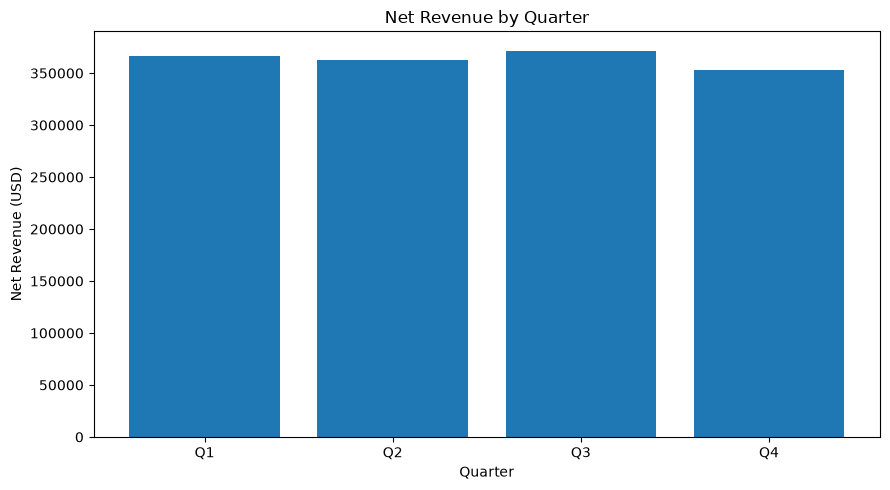

In [1241]:
# 1. Net revenue by quarter
quarterly_net_revenue = transactions.groupby("Quarter")["transaction_amount"].sum().reset_index()

plt.figure(figsize=(9, 5))
plt.bar(quarterly_net_revenue["Quarter"], quarterly_net_revenue["transaction_amount"])
plt.title("Net Revenue by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Net Revenue (USD)")
plt.tight_layout()
plt.show()

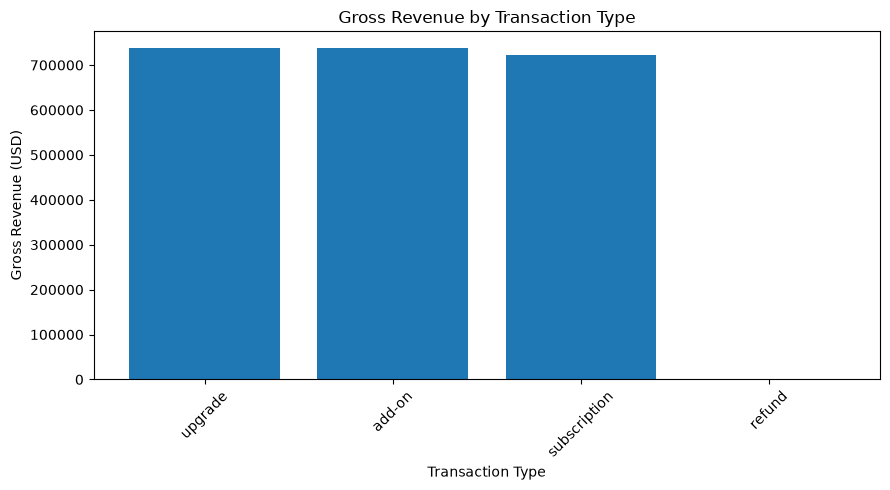

In [1242]:
# 2. Revenue by transaction type
plt.figure(figsize=(9,5))
plot_df = type_revenue.reset_index(name="gross_revenue")
plt.bar(plot_df["transaction_type"], plot_df["gross_revenue"])
plt.title("Gross Revenue by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Gross Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


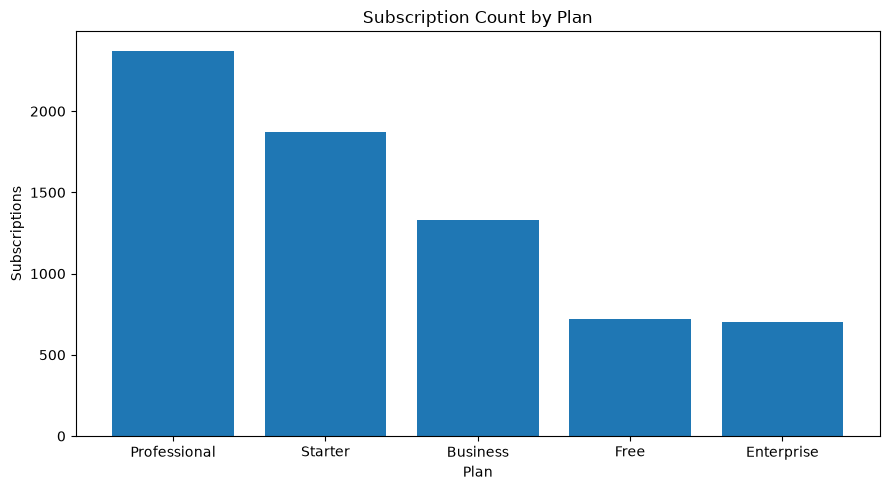

In [1243]:
# 3. Subscription plan distribution
plt.figure(figsize=(9,5))
plt.bar(plan_count.index, plan_count.values)
plt.title("Subscription Count by Plan")
plt.xlabel("Plan")
plt.ylabel("Subscriptions")
plt.tight_layout()
plt.show()


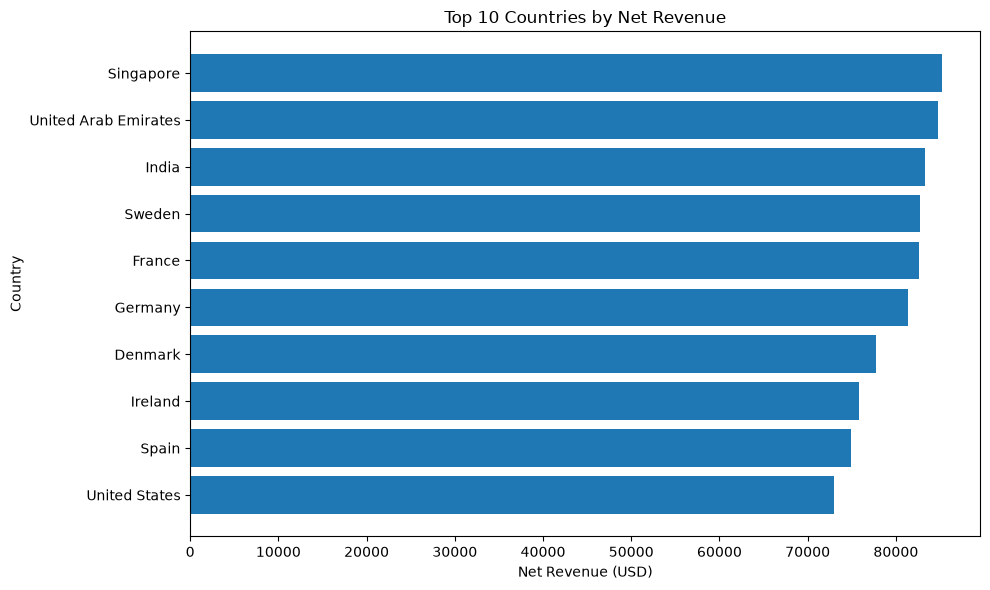

In [1244]:
# 4. Net revenue by country
plt.figure(figsize=(10,6))
country_plot = country_rev.head(10).sort_values()
plt.barh(country_plot.index, country_plot.values)
plt.title("Top 10 Countries by Net Revenue")
plt.xlabel("Net Revenue (USD)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

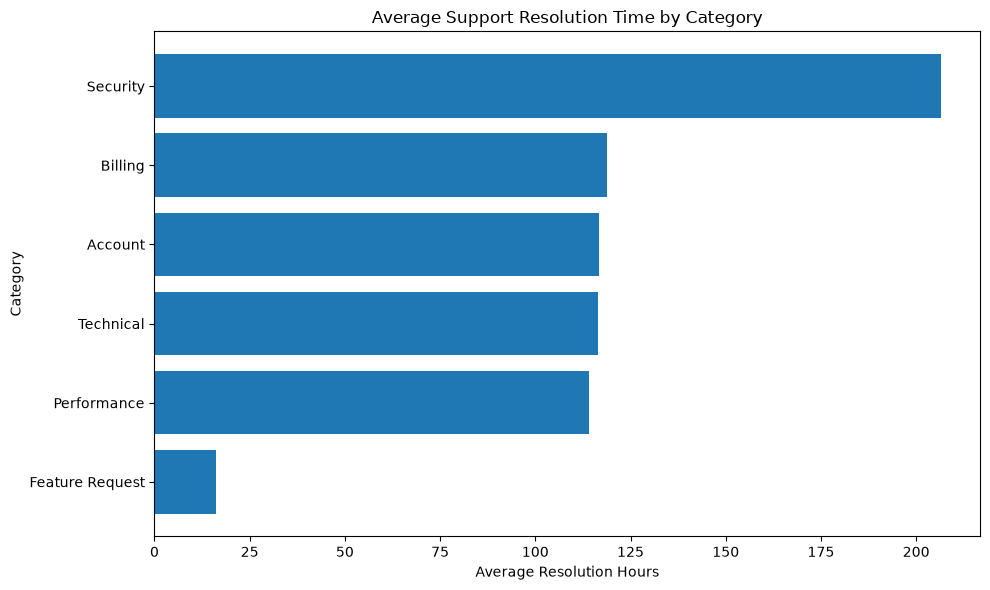

In [1245]:
# 5. Support resolution time by category
plt.figure(figsize=(10,6))
resolution_plot = category_resolution.sort_values()
plt.barh(resolution_plot.index, resolution_plot.values)
plt.title("Average Support Resolution Time by Category")
plt.xlabel("Average Resolution Hours")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

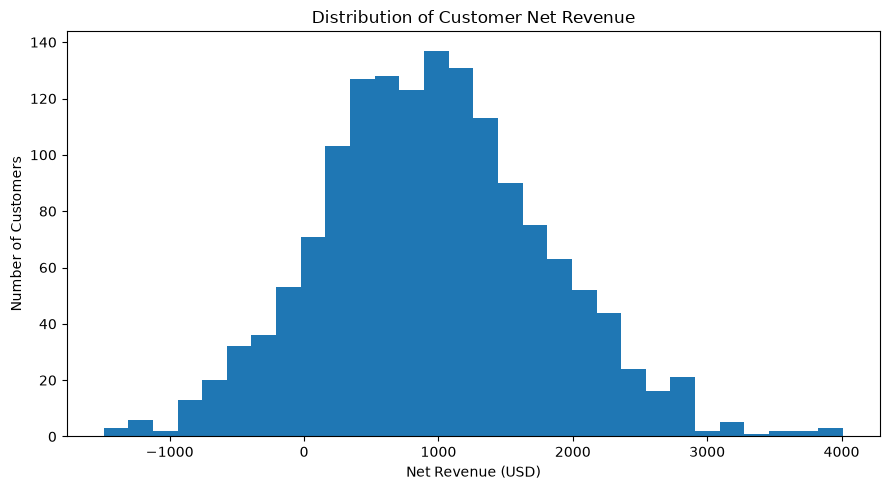

In [1246]:
# 6. Customer revenue distribution
plt.figure(figsize=(9,5))
plt.hist(customer360["net_revenue"].dropna(), bins=30)
plt.title("Distribution of Customer Net Revenue")
plt.xlabel("Net Revenue (USD)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


## 12. Summary and recommendations

### Key findings

- The strongest quarter by net revenue was **Q3**, generating approximately **$$371,618**.
- **Upgrade** transactions produced the largest share of gross revenue.
- **Singapore** generated the highest total customer net revenue approximately **$85,272**.
- The highest average monthly subscription fee was associated with the **Enterprise** plan **$817.07**.
- The support category with the longest average resolution time was **Security** at **206.4 hours**.

### Recommendations

1. **Protect high-value customers:** prioritize customers with high net revenue and active subscriptions for retention and proactive support.
2. **Monitor quarterly revenue:** investigate the drivers behind **Q3** performance.
3. **Create an ongoing Customer 360 dashboard:** refresh customer revenue, subscription status, campaign engagement, and support experience together so commercial and customer-success teams can act from one view.
'''

In [1250]:
customer360.to_csv(r"D:\Data Analysis\Python\Datasets\Customer 360/customer360.csv", index=False)